**Studi Kasus: Crop Yield Prediction Dataset (1990–2022)**

---

### Daftar Isi
1. Business Understanding
2. Temuan Kunci
3. Data Understanding
4. Data Preparation
5. Modelling
6. Evaluation
7. Deployment
8. Kesimpulan

# 1. Pemahaman Bisnis (Business Understanding)

## Latar Belakang

Menurut laporan terbaru FAO (The State of Food Security and Nutrition in the World 2025), sekitar 670 juta orang di dunia masih mengalami kelaparan pada tahun 2024, dan target SDG 2 (Zero Hunger) pada 2030 diperkirakan tidak akan tercapai. Salah satu akar masalahnya adalah ketidakpastian produktivitas pertanian akibat variasi iklim dan pengelolaan sumber daya yang berbeda antar wilayah.

Dataset yang digunakan dalam analisis ini mencakup data hasil panen dari berbagai negara pada periode 1990–2022, beserta faktor curah hujan, suhu rata-rata, dan penggunaan pestisida. Dengan memodelkan hubungan antara faktor-faktor tersebut dan hasil panen, analisis ini diharapkan dapat mendukung estimasi produktivitas pertanian sebagai salah satu alat bantu perencanaan produksi pangan, sejalan dengan SDG 2 (Zero Hunger) dan SDG 13 (Climate Action).

## Tujuan

Membangun model untuk memprediksi hasil panen (hg/ha) berdasarkan:

- Wilayah (Area)
- Jenis tanaman (Item)
- Tahun
- Curah hujan
- Penggunaan pestisida
- Suhu rata-rata

## Tujuan Analisis

1. Mengidentifikasi pola hasil panen.
2. Mengetahui kontribusi faktor terhadap prediksi yield.
3. Membangun model prediksi yang memiliki performa baik.
4. Menghasilkan simulasi prediksi yang dapat digunakan sebagai
   decision-support sederhana.

## Batasan

Dataset bersifat observasional sehingga hubungan yang ditemukan
merupakan asosiasi dan tidak dapat langsung dianggap sebagai
hubungan sebab-akibat. Selain itu, terdapat kesenjangan waktu (temporal gap) yang perlu diperhatikan antara konteks permasalahan dan data yang dianalisis.

Latar belakang analisis ini merujuk pada laporan FAO tahun 2025 mengenai kondisi ketahanan pangan global saat ini, sementara dataset yang digunakan hanya mencakup periode 1990–2022 — lebih dari satu dekade sebelum kondisi yang digambarkan dalam laporan tersebut. Akibatnya, pola dan hubungan yang ditemukan dalam analisis ini (misalnya dominasi faktor wilayah dan jenis tanaman dibandingkan cuaca tahunan) mencerminkan kondisi agrikultur pada periode 1990–2022 dan belum tentu sepenuhnya merepresentasikan kondisi pertanian, teknologi budidaya, maupun pola iklim saat ini.

Perubahan iklim yang semakin signifikan dalam satu dekade terakhir juga berpotensi mengubah kekuatan hubungan antara faktor cuaca dan hasil panen dibandingkan yang teramati pada data historis ini. Oleh karena itu, hasil dan model dalam analisis ini sebaiknya dipandang sebagai studi kasus historis dan titik awal, bukan sebagai alat prediksi yang siap pakai untuk kondisi pertanian terkini tanpa validasi ulang menggunakan data yang lebih mutakhir.

# 2. Temuan Kunci

> **Wilayah, jenis tanaman, dan riwayat hasil panen menjadi informasi penting dalam memprediksi hasil panen.**

Model awal pada notebook digunakan sebagai pembanding. Untuk meningkatkan performa prediksi, ditambahkan fitur lag hasil panen (`yield_lag_1`, `yield_lag_2`, dan `yield_lag_3`) berdasarkan kombinasi wilayah dan jenis tanaman. Model CatBoost kemudian digunakan karena dapat menangani fitur kategorikal `Area` dan `Item` secara langsung.

Pada pengujian dengan pembagian waktu yang sama (data pelatihan sampai 2009 dan data pengujian setelah 2009), kombinasi CatBoost + lag menghasilkan **R² = 0,9067 atau 90,67%**. Nilai ini merupakan hasil pada data pengujian.


# 3. Pemahaman Data (Data Understanding)

In [5]:
"""
from google.colab import files
uploaded = files.upload()
"""

'\nfrom google.colab import files\nuploaded = files.upload()\n'

In [ ]:
# Import library pandas untuk melakukan pengolahan dan analisis data
import pandas as pd

# Membaca dataset crop yield dari file CSV
df = pd.read_csv("data/yield_df.csv")

# Menampilkan ukuran dataset (jumlah baris dan kolom)
print("Ukuran dataset:", df.shape)

# Menampilkan 5 baris pertama dari dataset
df.head()

Ukuran dataset: (37240, 7)


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Maize,1991,29068,1485.0,121.0,15.36
2,Albania,Maize,1992,24876,1485.0,121.0,16.06
3,Albania,Maize,1993,24185,1485.0,121.0,16.05
4,Albania,Maize,1994,25848,1485.0,201.0,16.96


Pada tahap awal, dataset dimuat menggunakan Pandas dan kemudian dilakukan pengecekan terhadap ukuran serta beberapa data pertama. Dataset yang digunakan memiliki 37.240 baris dan 7 kolom. Data ini berisi informasi mengenai wilayah, jenis tanaman, tahun, hasil produksi per hektare, curah hujan, penggunaan pestisida, dan suhu. Pengecekan lima data pertama dilakukan untuk memastikan struktur dan isi dataset sudah sesuai dengan kebutuhan analisis.

## Kamus Fitur (Data Dictionary)

Dataset ini terdiri dari 37.240 baris dan 7 kolom, dengan rincian sebagai berikut:

| Kolom | Deskripsi | Satuan/Tipe |
|---|---|---|
| `Area` | Nama negara/wilayah tempat pengamatan dilakukan | Kategorikal |
| `Item` | Jenis tanaman yang diamati (contoh: Maize, Potatoes, Rice) | Kategorikal |
| `Year` | Tahun pengamatan | 1990–2022 |
| `hg/ha_yield` | Hasil panen per hektar lahan (variabel target) | Hektogram/hektar (hg/ha) |
| `average_rain_fall_mm_per_year` | Rata-rata curah hujan tahunan di wilayah tersebut | Milimeter (mm) |
| `pesticides_tonnes` | Total penggunaan pestisida di wilayah tersebut | Ton |
| `avg_temp` | Suhu rata-rata tahunan di wilayah tersebut | Derajat Celsius (°C) |

Catatan: 1 ton/ha setara dengan 10.000 hg/ha, sehingga sepanjang analisis nilai hasil panen sering dikonversi ke ton/ha agar lebih mudah diinterpretasikan.

In [7]:
# Menghitung jumlah nilai yang hilang pada setiap kolom
missing = df.isnull().sum()

# Menampilkan jumlah nilai yang hilang pada setiap kolom
print("Jumlah nilai yang hilang:")
print(missing)

# Menampilkan total seluruh nilai yang hilang dalam dataset
print("\nTotal nilai yang hilang:", missing.sum())

Jumlah nilai yang hilang:
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Total nilai yang hilang: 0


In [8]:
# Menghitung dan menampilkan jumlah data yang memiliki baris duplikat
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 2310


In [9]:
# Menghapus data duplikat dari dataset
df = df.drop_duplicates()

# Menampilkan ukuran dataset setelah data duplikat dihapus
print("Ukuran dataset setelah menghapus duplikat:", df.shape)

Ukuran dataset setelah menghapus duplikat: (34930, 7)


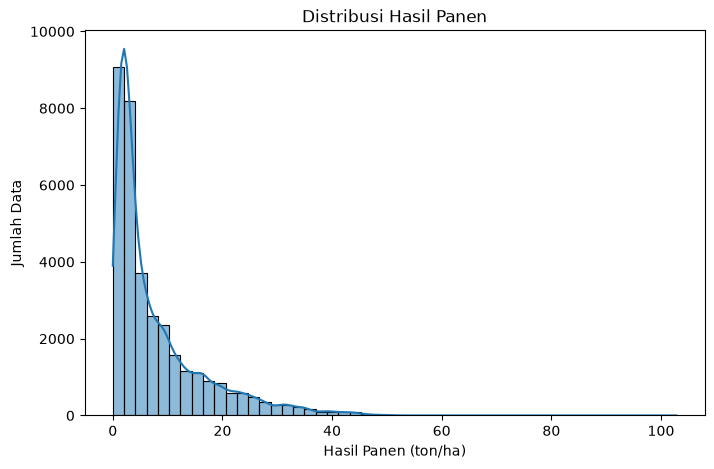

In [10]:
# Mengimpor pustaka untuk membuat visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur ukuran gambar visualisasi
plt.figure(figsize=(8,5))

# Membuat grafik distribusi hasil panen
# Membagi nilai hg/ha_yield dengan 10.000 untuk mengubah satuan menjadi ton/ha
sns.histplot(
    df["hg/ha_yield"] / 10000,
    bins=50,
    kde=True
)

# Memberikan judul dan nama pada sumbu grafik
plt.title("Distribusi Hasil Panen")
plt.xlabel("Hasil Panen (ton/ha)")
plt.ylabel("Jumlah Data")

# Menampilkan grafik
plt.show()

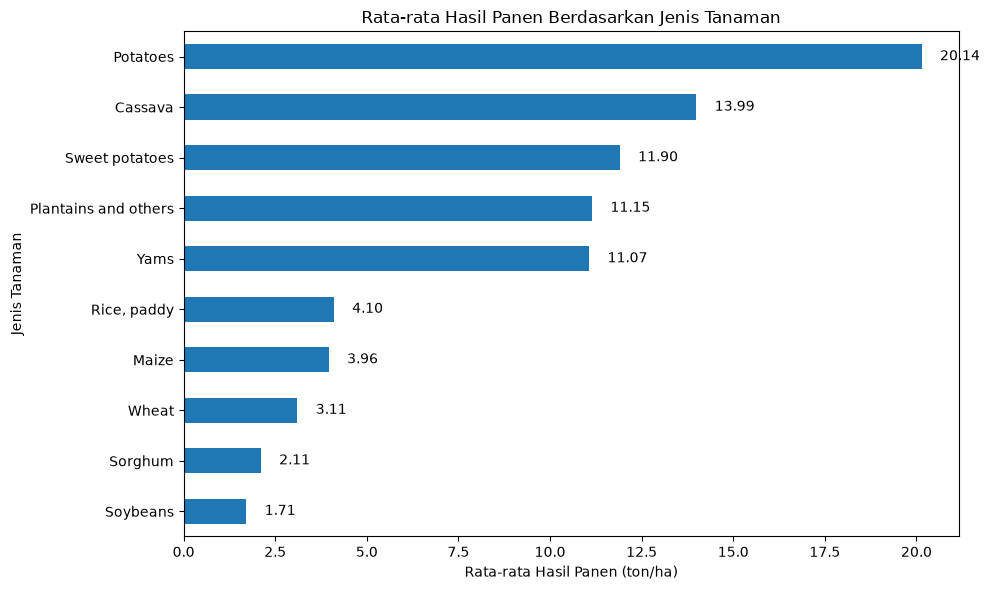

In [11]:
# Mengelompokkan data berdasarkan jenis tanaman dan menghitung rata-rata hasil panen
yield_item = (
    df.groupby("Item")["hg/ha_yield"]
    .mean()
    .sort_values(ascending=False)
)

# Mengubah satuan hasil panen dari hg/ha menjadi ton/ha
yield_item = yield_item / 10000

# Mengurutkan data dari hasil panen terendah ke tertinggi
# agar tampilan grafik batang lebih mudah dibaca
yield_item = yield_item.sort_values()

# Mengatur ukuran grafik
plt.figure(figsize=(10, 6))

# Membuat grafik batang horizontal
ax = yield_item.plot(kind="barh")

# Memberikan judul dan keterangan pada sumbu grafik
plt.title("Rata-rata Hasil Panen Berdasarkan Jenis Tanaman")
plt.xlabel("Rata-rata Hasil Panen (ton/ha)")
plt.ylabel("Jenis Tanaman")

# Menampilkan nilai rata-rata pada setiap batang grafik
for i, value in enumerate(yield_item):
    ax.text(
        value + 0.5,
        i,
        f"{value:.2f}",
        va="center"
    )

# Mengatur tata letak grafik agar tidak saling bertumpuk
plt.tight_layout()

# Menampilkan grafik
plt.show()

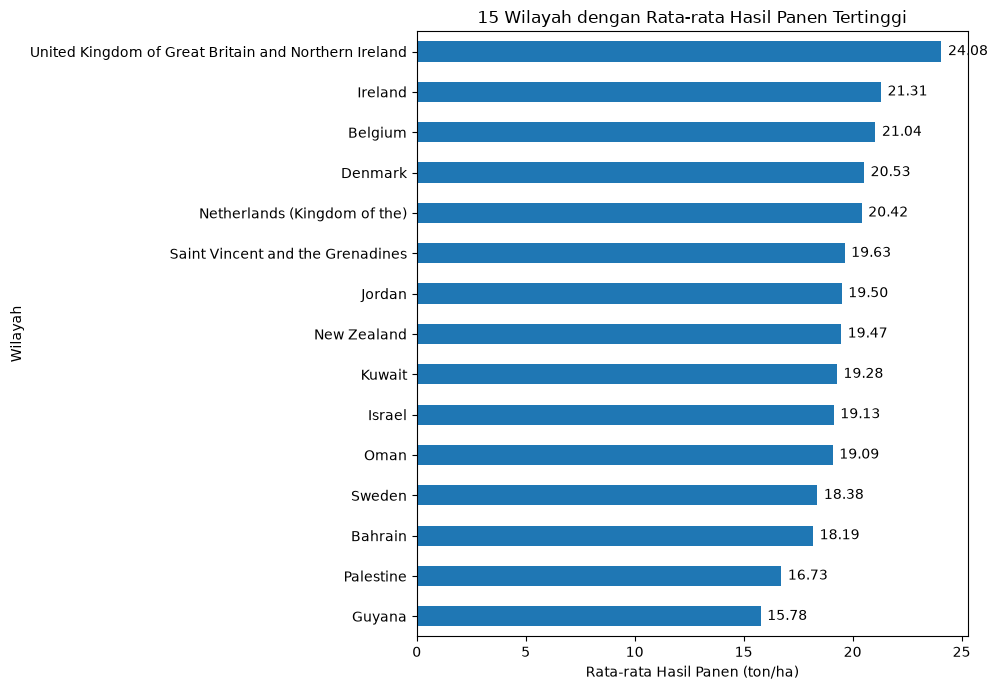

In [12]:
# Mengelompokkan data berdasarkan wilayah dan menghitung rata-rata hasil panen
# kemudian mengambil 15 wilayah dengan rata-rata hasil panen tertinggi
rata_area = (
    df.groupby("Area")["hg/ha_yield"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

# Mengubah satuan hasil panen dari hg/ha menjadi ton/ha
rata_area = rata_area / 10000

# Mengurutkan data dari hasil panen terendah ke tertinggi
# agar tampilan grafik lebih mudah dibaca
rata_area = rata_area.sort_values()

# Mengatur ukuran grafik
plt.figure(figsize=(10, 7))

# Membuat grafik batang horizontal
ax = rata_area.plot(
    kind="barh",
    figsize=(10, 7)
)

# Memberikan judul dan keterangan pada sumbu grafik
plt.title(
    "15 Wilayah dengan Rata-rata Hasil Panen Tertinggi"
)

plt.xlabel("Rata-rata Hasil Panen (ton/ha)")
plt.ylabel("Wilayah")

# Menampilkan nilai rata-rata pada setiap batang grafik
for i, value in enumerate(rata_area):
    ax.text(
        value + 0.3,
        i,
        f"{value:.2f}",
        va="center"
    )

# Mengatur tata letak grafik agar tidak saling bertumpuk
plt.tight_layout()

# Menampilkan grafik
plt.show()

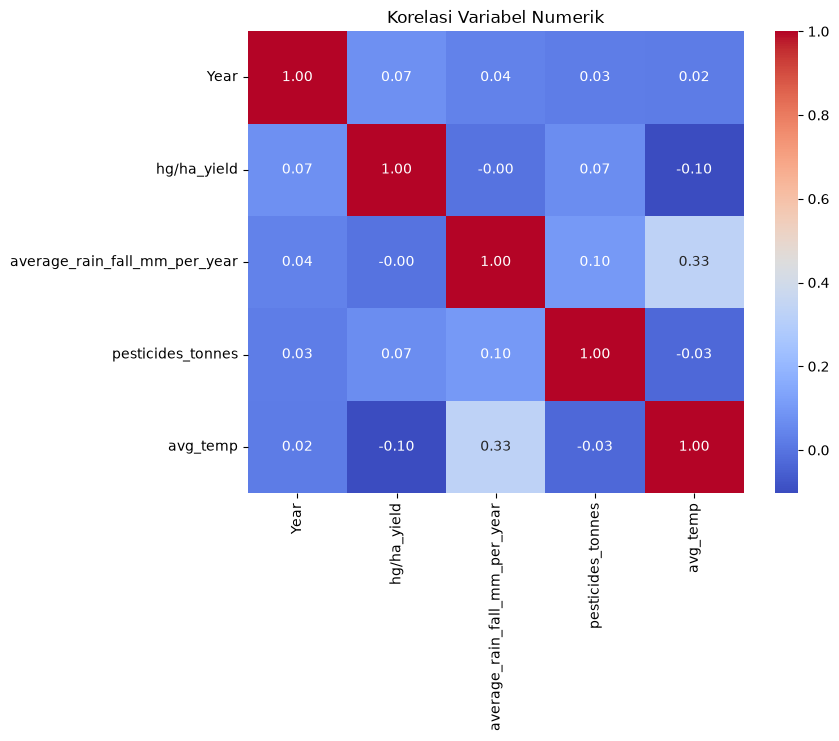

In [13]:
# Menentukan kolom numerik yang akan digunakan untuk analisis korelasi
numeric_cols = [
    "Year",
    "hg/ha_yield",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

# Mengatur ukuran grafik
plt.figure(figsize=(8, 6))

# Membuat peta panas untuk melihat hubungan antarvariabel numerik
# Nilai korelasi berada pada rentang -1 hingga 1
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# Memberikan judul pada grafik
plt.title("Korelasi Variabel Numerik")

# Menampilkan grafik
plt.show()

# 4. Persiapan Data (Data Preparation)

In [14]:
# Mengimpor pustaka NumPy untuk melakukan operasi matematika
import numpy as np

# Membuat kolom baru dengan menerapkan transformasi logaritma pada hasil panen
# log1p digunakan agar tetap aman ketika terdapat nilai hasil panen sebesar 0
df["log_yield"] = np.log1p(df["hg/ha_yield"])

# Menampilkan lima baris pertama untuk membandingkan nilai hasil panen
# sebelum dan sesudah transformasi logaritma
print(df[["hg/ha_yield", "log_yield"]].head())

   hg/ha_yield  log_yield
0        36613  10.508186
1        29068  10.277428
2        24876  10.121699
3        24185  10.093529
4        25848  10.160027


In [15]:
# Mengurutkan data berdasarkan wilayah, jenis tanaman, dan tahun
# agar fitur lag mengikuti urutan waktu yang benar
df = df.sort_values(
    ["Area", "Item", "Year"]
).reset_index(drop=True)

# Membuat lag hasil panen berdasarkan kombinasi wilayah dan jenis tanaman
# Lag 1 = hasil panen satu tahun sebelumnya
# Lag 2 = hasil panen dua tahun sebelumnya
# Lag 3 = hasil panen tiga tahun sebelumnya
df["yield_lag_1"] = (
    df.groupby(["Area", "Item"])["hg/ha_yield"]
    .shift(1)
)

df["yield_lag_2"] = (
    df.groupby(["Area", "Item"])["hg/ha_yield"]
    .shift(2)
)

df["yield_lag_3"] = (
    df.groupby(["Area", "Item"])["hg/ha_yield"]
    .shift(3)
)

# Menampilkan contoh hasil pembuatan fitur lag
print("Contoh fitur lag:")
print(
    df[[
        "Area",
        "Item",
        "Year",
        "hg/ha_yield",
        "yield_lag_1",
        "yield_lag_2",
        "yield_lag_3"
    ]].head(10)
)


Contoh fitur lag:
      Area   Item  Year  hg/ha_yield  yield_lag_1  yield_lag_2  yield_lag_3
0  Albania  Maize  1990        36613          NaN          NaN          NaN
1  Albania  Maize  1991        29068      36613.0          NaN          NaN
2  Albania  Maize  1992        24876      29068.0      36613.0          NaN
3  Albania  Maize  1993        24185      24876.0      29068.0      36613.0
4  Albania  Maize  1994        25848      24185.0      24876.0      29068.0
5  Albania  Maize  1995        31300      25848.0      24185.0      24876.0
6  Albania  Maize  1996        32604      31300.0      25848.0      24185.0
7  Albania  Maize  1997        31862      32604.0      31300.0      25848.0
8  Albania  Maize  1998        33416      31862.0      32604.0      31300.0
9  Albania  Maize  1999        37455      33416.0      31862.0      32604.0


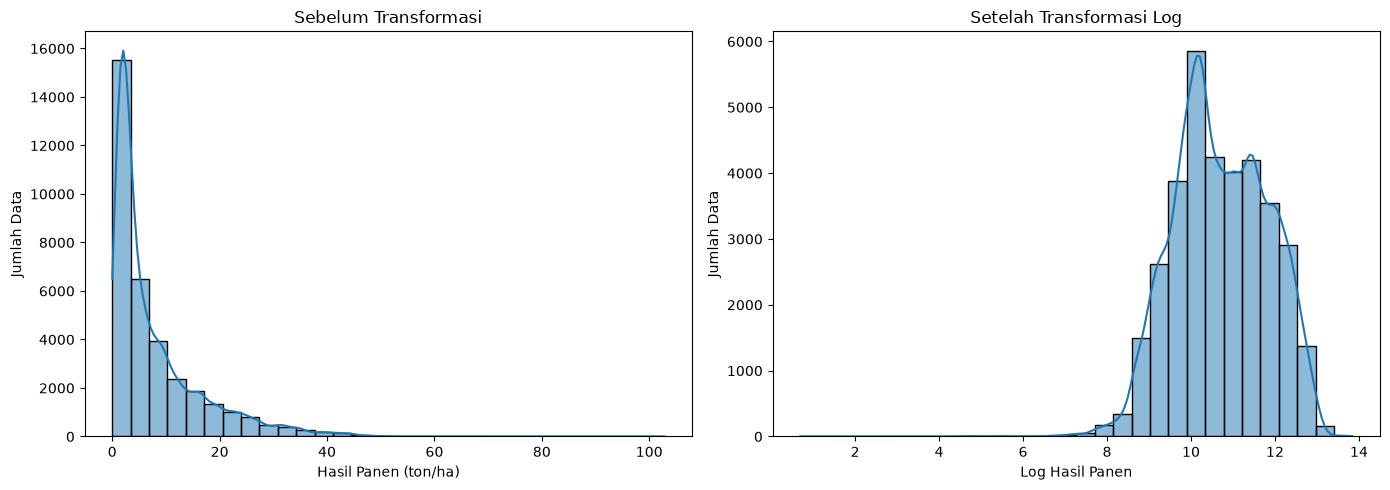

In [16]:
# Membuat dua grafik berdampingan untuk membandingkan distribusi data
# sebelum dan sesudah dilakukan transformasi logaritma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Membuat grafik distribusi hasil panen sebelum transformasi
sns.histplot(
    df["hg/ha_yield"] / 10000,
    bins=30,
    kde=True,
    ax=axes[0]
)

# Memberikan judul dan keterangan pada grafik pertama
axes[0].set_title("Sebelum Transformasi")
axes[0].set_xlabel("Hasil Panen (ton/ha)")
axes[0].set_ylabel("Jumlah Data")


# Membuat grafik distribusi hasil panen setelah transformasi logaritma
sns.histplot(
    df["log_yield"],
    bins=30,
    kde=True,
    ax=axes[1]
)

# Memberikan judul dan keterangan pada grafik kedua
axes[1].set_title("Setelah Transformasi Log")
axes[1].set_xlabel("Log Hasil Panen")
axes[1].set_ylabel("Jumlah Data")

# Mengatur tata letak agar kedua grafik tidak saling bertumpuk
plt.tight_layout()

# Menampilkan kedua grafik
plt.show()

In [17]:
# Menentukan tahun terakhir yang digunakan untuk data pelatihan
TRAIN_CUTOFF = 2009

# Membagi data menjadi data pelatihan dan data pengujian berdasarkan tahun
# Data dengan tahun 2009 atau sebelumnya digunakan untuk pelatihan
train_df = df[df["Year"] <= TRAIN_CUTOFF].copy()

# Data setelah tahun 2009 digunakan untuk pengujian
test_df = df[df["Year"] > TRAIN_CUTOFF].copy()

# Menampilkan ukuran data pelatihan dan data pengujian
print("Data pelatihan:", train_df.shape)
print("Data pengujian :", test_df.shape)

# Menampilkan rentang tahun yang terdapat pada data pelatihan
print("\nTahun data pelatihan:",
      train_df["Year"].min(),
      "-",
      train_df["Year"].max())

# Menampilkan rentang tahun yang terdapat pada data pengujian
print("Tahun data pengujian :",
      test_df["Year"].min(),
      "-",
      test_df["Year"].max())

Data pelatihan: (21305, 11)
Data pengujian : (13625, 11)

Tahun data pelatihan: 1990 - 2009
Tahun data pengujian : 2010 - 2022


In [18]:
# Menghitung rata-rata hasil panen berdasarkan kombinasi wilayah dan jenis tanaman
# dari data pelatihan sebagai dasar untuk membuat prediksi
baseline_map = (
    train_df
    .groupby(["Area", "Item"])["log_yield"]
    .mean()
)

# Menghitung rata-rata hasil panen secara keseluruhan dari data pelatihan
# yang digunakan sebagai nilai cadangan jika kombinasi wilayah dan tanaman tidak ditemukan
global_mean = train_df["log_yield"].mean()


# Membuat fungsi untuk menghasilkan prediksi menggunakan model dasar
def get_baseline_prediction(data):
    return data.apply(
        lambda row: baseline_map.get(
            (row["Area"], row["Item"]),
            global_mean
        ),
        axis=1
    )


# Menghasilkan prediksi model dasar untuk data pelatihan
train_df["baseline_log_pred"] = get_baseline_prediction(train_df)

# Menghasilkan prediksi model dasar untuk data pengujian
test_df["baseline_log_pred"] = get_baseline_prediction(test_df)

In [19]:
# Menghitung selisih antara nilai hasil panen sebenarnya
# dengan hasil prediksi dari model dasar pada data pelatihan
train_df["residual"] = (
    train_df["log_yield"]
    - train_df["baseline_log_pred"]
)

# Menghitung selisih antara nilai hasil panen sebenarnya
# dengan hasil prediksi dari model dasar pada data pengujian
test_df["residual"] = (
    test_df["log_yield"]
    - test_df["baseline_log_pred"]
)

# Menampilkan ringkasan statistik dari nilai selisih pada data pelatihan
print(train_df["residual"].describe())

count    2.130500e+04
mean    -1.179791e-17
std      2.182161e-01
min     -2.503371e+00
25%     -8.704176e-02
50%      3.396852e-03
75%      9.413184e-02
max      2.298740e+00
Name: residual, dtype: float64


In [20]:
# Menentukan variabel yang akan digunakan sebagai fitur dalam pemodelan
FEATURES = [
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

# Menambahkan fitur interaksi sederhana antara curah hujan dan suhu
# Fitur ini digunakan untuk menangkap kemungkinan hubungan antara kedua variabel
for data in [train_df, test_df]:

    data["rainfall_temp"] = (
        data["average_rain_fall_mm_per_year"]
        * data["avg_temp"]
    )

# Menambahkan fitur interaksi yang telah dibuat ke dalam daftar fitur
FEATURES += [
    "rainfall_temp"
]

In [21]:
# Mengubah kategori jenis tanaman pada data pelatihan menjadi variabel biner
# menggunakan metode pengkodean satu-panas
item_train = pd.get_dummies(
    train_df["Item"],
    prefix="item"
)

# Mengubah kategori jenis tanaman pada data pengujian menjadi variabel biner
# menggunakan metode pengkodean satu-panas
item_test = pd.get_dummies(
    test_df["Item"],
    prefix="item"
)

# Menyamakan kolom pada data pelatihan dan data pengujian
# agar keduanya memiliki struktur fitur yang sama
item_test = item_test.reindex(
    columns=item_train.columns,
    fill_value=0
)

In [22]:
# Menggabungkan fitur numerik dengan fitur jenis tanaman yang telah diubah
# menjadi variabel biner untuk membentuk data masukan pelatihan
X_train = pd.concat(
    [
        train_df[FEATURES].reset_index(drop=True),
        item_train.reset_index(drop=True)
    ],
    axis=1
)

# Menggabungkan fitur numerik dengan fitur jenis tanaman yang telah diubah
# menjadi variabel biner untuk membentuk data masukan pengujian
X_test = pd.concat(
    [
        test_df[FEATURES].reset_index(drop=True),
        item_test.reset_index(drop=True)
    ],
    axis=1
)

# Menentukan nilai target yang akan dipelajari oleh model
# Target berupa selisih antara hasil sebenarnya dan prediksi model dasar
y_train = train_df["residual"]
y_test = test_df["residual"]

# Menampilkan jumlah fitur serta ukuran data pelatihan dan pengujian
print("Jumlah fitur:", X_train.shape[1])
print("Data pelatihan:", X_train.shape)
print("Data pengujian :", X_test.shape)

Jumlah fitur: 15
Data pelatihan: (21305, 15)
Data pengujian : (13625, 15)


# 5. Pemodelan (Modelling)

In [23]:
# Menginstal CatBoost di Google Colab
!pip install catboost -q


In [24]:
# PEMODELAN - PERBANDINGAN BEBERAPA ALGORITMA

# Mengimpor algoritma yang akan digunakan untuk pemodelan
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Membuat model Regresi Linear
linear_model = LinearRegression()

# Melatih model menggunakan data pelatihan
linear_model.fit(
    X_train,
    y_train
)

# Menampilkan informasi bahwa model telah berhasil dilatih
print("Regresi Linear berhasil dilatih.")

# Membuat model Random Forest dengan 300 pohon keputusan
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Melatih model menggunakan data pelatihan
rf_model.fit(
    X_train,
    y_train
)

# Menampilkan informasi bahwa model telah berhasil dilatih
print("Random Forest berhasil dilatih.")

# Membuat model XGBoost dengan parameter yang telah ditentukan
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Melatih model menggunakan data pelatihan
xgb_model.fit(
    X_train,
    y_train
)

# Menampilkan informasi bahwa model telah berhasil dilatih
print("XGBoost berhasil dilatih.")

# Mengimpor CatBoost untuk model dengan fitur kategorikal Area dan Item
from catboost import CatBoostRegressor

# Menentukan fitur kategorikal yang digunakan CatBoost
CAT_FEATURES = [
    "Area",
    "Item"
]

# Menentukan fitur numerik dan fitur lag
NUM_FEATURES = [
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp",
    "yield_lag_1",
    "yield_lag_2",
    "yield_lag_3"
]

# Membentuk data masukan khusus CatBoost
X_train_cat = train_df[
    CAT_FEATURES + NUM_FEATURES
].copy()

X_test_cat = test_df[
    CAT_FEATURES + NUM_FEATURES
].copy()

# Target menggunakan transformasi logaritma
y_train_cat = np.log1p(
    train_df["hg/ha_yield"]
)

# Membuat model CatBoost dengan parameter hasil optimasi
cat_model = CatBoostRegressor(
    iterations=1500,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

# Melatih CatBoost menggunakan Area dan Item sebagai fitur kategorikal
cat_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=CAT_FEATURES
)

print("CatBoost berhasil dilatih.")


Regresi Linear berhasil dilatih.
Random Forest berhasil dilatih.
XGBoost berhasil dilatih.
CatBoost berhasil dilatih.


In [25]:
# MENGHASILKAN PREDIKSI NILAI SELISIH

# Menghasilkan prediksi nilai selisih menggunakan model Regresi Linear
predicted_residual_linear = linear_model.predict(X_test)

# Menghasilkan prediksi nilai selisih menggunakan model Random Forest
predicted_residual_rf = rf_model.predict(X_test)

# Menghasilkan prediksi nilai selisih menggunakan model XGBoost
predicted_residual_xgb = xgb_model.predict(X_test)

# MENGGABUNGKAN PREDIKSI DENGAN NILAI DASAR

# Menggabungkan prediksi nilai dasar dengan prediksi selisih
# untuk memperoleh prediksi dalam skala logaritma
predicted_log_linear = (
    test_df["baseline_log_pred"].values
    + predicted_residual_linear
)

predicted_log_rf = (
    test_df["baseline_log_pred"].values
    + predicted_residual_rf
)

predicted_log_xgb = (
    test_df["baseline_log_pred"].values
    + predicted_residual_xgb
)

# MENGEMBALIKAN KE SKALA ASLI

predicted_yield_linear = np.expm1(predicted_log_linear)
predicted_yield_rf = np.expm1(predicted_log_rf)
predicted_yield_xgb = np.expm1(predicted_log_xgb)

# MEMASTIKAN HASIL PREDIKSI TIDAK NEGATIF
predicted_yield_linear = np.clip(
    predicted_yield_linear, 0, None
)

predicted_yield_rf = np.clip(
    predicted_yield_rf, 0, None
)

predicted_yield_xgb = np.clip(
    predicted_yield_xgb, 0, None
)

# MENGHASILKAN PREDIKSI CATBOOST

# CatBoost memprediksi target logaritma secara langsung
predicted_log_cat = cat_model.predict(
    X_test_cat
)

# Mengembalikan hasil prediksi CatBoost dari skala logaritma
# ke skala hasil panen asli
predicted_yield_cat = np.expm1(
    predicted_log_cat
)

# Memastikan hasil prediksi tidak negatif
predicted_yield_cat = np.clip(
    predicted_yield_cat,
    0,
    None
)


# 6. Evaluasi (Evaluation)

In [26]:
# Mengimpor metrik untuk mengevaluasi kinerja model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# EVALUASI SEMUA MODEL
actual_yield = test_df["hg/ha_yield"].values

# 1. Regresi Linear
mae_linear = mean_absolute_error(actual_yield, predicted_yield_linear)
rmse_linear = np.sqrt(mean_squared_error(actual_yield, predicted_yield_linear))
r2_linear = r2_score(actual_yield, predicted_yield_linear)

# 2. Random Forest
mae_rf = mean_absolute_error(actual_yield, predicted_yield_rf)
rmse_rf = np.sqrt(mean_squared_error(actual_yield, predicted_yield_rf))
r2_rf = r2_score(actual_yield, predicted_yield_rf)

# 3. XGBoost
mae_xgb = mean_absolute_error(actual_yield, predicted_yield_xgb)
rmse_xgb = np.sqrt(mean_squared_error(actual_yield, predicted_yield_xgb))
r2_xgb = r2_score(actual_yield, predicted_yield_xgb)

# 4. CatBoost + Lag
mae_cat = mean_absolute_error(actual_yield, predicted_yield_cat)
rmse_cat = np.sqrt(mean_squared_error(actual_yield, predicted_yield_cat))
r2_cat = r2_score(actual_yield, predicted_yield_cat)

# MENAMPILKAN HASIL EVALUASI
print("=== HASIL EVALUASI ===")

print("\nRegresi Linear")
print(f"MAE  : {mae_linear:,.2f}")
print(f"RMSE : {rmse_linear:,.2f}")
print(f"R²   : {r2_linear:.4f}")

print("\nRandom Forest")
print(f"MAE  : {mae_rf:,.2f}")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")

print("\nXGBoost")
print(f"MAE  : {mae_xgb:,.2f}")
print(f"RMSE : {rmse_xgb:,.2f}")
print(f"R²   : {r2_xgb:.4f}")

print("\nCatBoost + Lag")
print(f"MAE  : {mae_cat:,.2f}")
print(f"RMSE : {rmse_cat:,.2f}")
print(f"R²   : {r2_cat:.4f}")
print(f"R² (%) : {r2_cat * 100:.2f}%")


=== HASIL EVALUASI ===

Regresi Linear
MAE  : 28,868.62
RMSE : 57,855.97
R²   : 0.6230

Random Forest
MAE  : 26,963.49
RMSE : 57,541.37
R²   : 0.6270

XGBoost
MAE  : 27,960.00
RMSE : 58,131.95
R²   : 0.6194

CatBoost + Lag
MAE  : 9,500.20
RMSE : 28,775.86
R²   : 0.9067
R² (%) : 90.67%


In [27]:
# EVALUASI MODEL DASAR

# Mengubah prediksi dari skala logaritma kembali ke skala asli
baseline_predicted = np.expm1(test_df["baseline_log_pred"])
baseline_predicted = np.clip(baseline_predicted, 0, None)

# Menghitung metrik model dasar
baseline_r2 = r2_score(actual_yield, baseline_predicted)
baseline_mae = mean_absolute_error(actual_yield, baseline_predicted)

print("\nBASELINE")
print(f"MAE : {baseline_mae:,.2f}")
print(f"R²  : {baseline_r2:.4f}")

print("\nREGRESI LINEAR")
print(f"MAE : {mae_linear:,.2f}")
print(f"R²  : {r2_linear:.4f}")
print(f"Peningkatan R²: {r2_linear - baseline_r2:.4f}")

print("\nRANDOM FOREST")
print(f"MAE : {mae_rf:,.2f}")
print(f"R²  : {r2_rf:.4f}")
print(f"Peningkatan R²: {r2_rf - baseline_r2:.4f}")

print("\nXGBOOST")
print(f"MAE : {mae_xgb:,.2f}")
print(f"R²  : {r2_xgb:.4f}")
print(f"Peningkatan R²: {r2_xgb - baseline_r2:.4f}")

print("\nCATBOOST + LAG")
print(f"MAE : {mae_cat:,.2f}")
print(f"R²  : {r2_cat:.4f}")
print(f"R² (%) : {r2_cat * 100:.2f}%")
print(f"Peningkatan R²: {r2_cat - baseline_r2:.4f}")



BASELINE
MAE : 31,658.92
R²  : 0.5613

REGRESI LINEAR
MAE : 28,868.62
R²  : 0.6230
Peningkatan R²: 0.0617

RANDOM FOREST
MAE : 26,963.49
R²  : 0.6270
Peningkatan R²: 0.0658

XGBOOST
MAE : 27,960.00
R²  : 0.6194
Peningkatan R²: 0.0581

CATBOOST + LAG
MAE : 9,500.20
R²  : 0.9067
R² (%) : 90.67%
Peningkatan R²: 0.3455


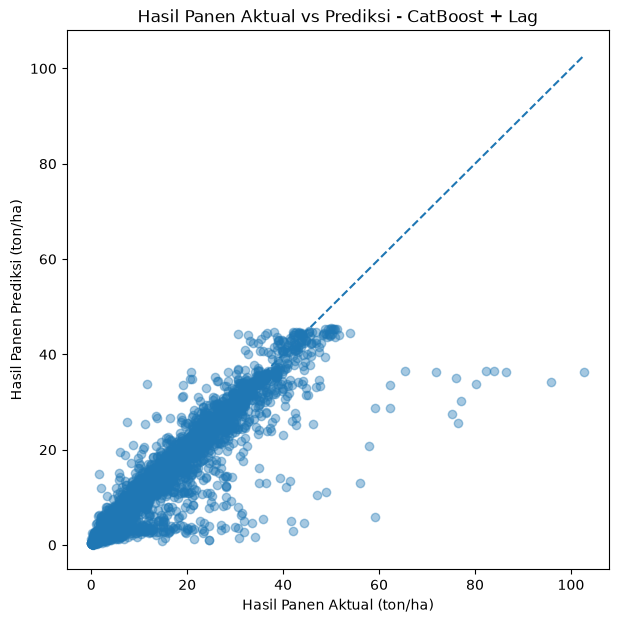

In [28]:
# Mengimpor pustaka untuk membuat visualisasi
import matplotlib.pyplot as plt

# MENGUBAH SATUAN DARI hg/ha KE ton/ha
actual_yield_ton = actual_yield / 10000
predicted_yield_cat_ton = predicted_yield_cat / 10000

# MEMBUAT GRAFIK HASIL PANEN AKTUAL VS PREDIKSI
plt.figure(figsize=(7, 7))
plt.scatter(
    actual_yield_ton,
    predicted_yield_cat_ton,
    alpha=0.4
)

min_val = min(
    actual_yield_ton.min(),
    predicted_yield_cat_ton.min()
)

max_val = max(
    actual_yield_ton.max(),
    predicted_yield_cat_ton.max()
)

# Garis diagonal menunjukkan kondisi ketika prediksi sama dengan aktual
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Hasil Panen Aktual (ton/ha)")
plt.ylabel("Hasil Panen Prediksi (ton/ha)")
plt.title("Hasil Panen Aktual vs Prediksi - CatBoost + Lag")
plt.show()


# 7. Penerapan (Deployment)

In [29]:
import joblib

# Simpan model terbaik, yaitu CatBoost + Lag
joblib.dump(
    cat_model,
    "catboost_lag_model.pkl"
)

print("Artefak berhasil disimpan:")
print("catboost_lag_model.pkl")


Artefak berhasil disimpan:
catboost_lag_model.pkl
